![Astrofisica Computacional](../../new_logo.png)

# Computational Astrophysics – Creation of Synthetic Data: signals+noise

## Dr. rer. nat. Jose Ivan Campos Rozo<sup>1,2</sup>

1. Astronomical Institute of the Czech Academy of Sciences\
   Department of Solar Physics\
   Ondřejov, Czec Republic

2. Observatorio Astronómico Nacional\
   Facultad de Ciencias\
   Universidad Nacional de Colombia

e-mail: jicamposr@unal.edu.co & rozo@asu.cas.cz)

---
Taken from previous lectures of this course.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

Synthetic Signal

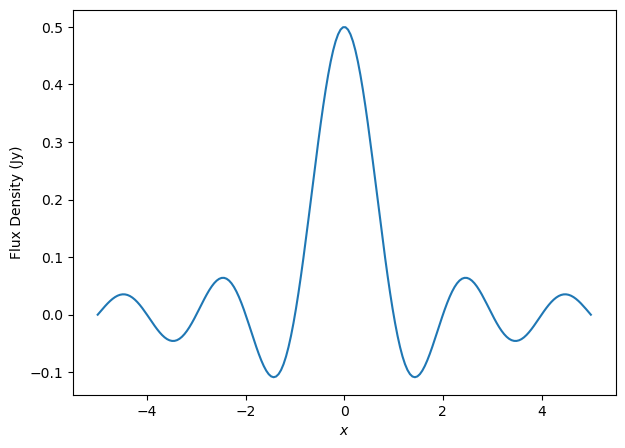

In [2]:
x = np.linspace(-5, 5, 200)
y = 0.5*np.sinc(x)

fig, ax = plt.subplots(figsize=(7,5))

ax.plot(x,y)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'Flux Density (Jy)')
plt.show()


Creation of 100 synthetic profiles using the above signal and adding random noise.

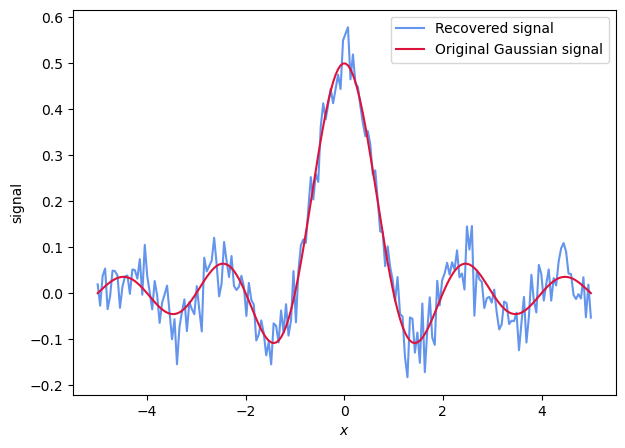

In [3]:
n = 100
rawprofiles = np.zeros([n,200])
for i in range(n):
  rawprofiles[i] = y + ( np.random.rand(200) - np.random.rand(200) )

recovered_signal = np.mean(rawprofiles, axis=0)

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(x,recovered_signal, label='Recovered signal', color='cornflowerblue')
ax.plot(x,y, label='Original Gaussian signal', color='crimson')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'signal')
plt.legend()
plt.show()

In [4]:
rawprofiles[0]

array([-0.43003879,  0.40394472, -0.13311455, -0.18692151,  0.07078128,
       -0.2740907 , -0.4067001 ,  0.17629625,  0.7929593 , -0.11900943,
       -0.18496325, -0.30394116,  0.06970087,  0.07081755,  0.13108267,
       -0.25426004,  0.0573158 , -0.04790762, -0.96784698,  0.79289732,
        0.36801616, -0.00739595,  0.46987113, -0.64293715, -0.18640162,
        0.58749792, -0.10826724,  0.43345912, -0.37644746, -0.29972247,
       -0.02697168,  0.25226587, -0.1894728 , -0.66301585, -0.02318431,
        0.39853975, -0.86350789, -0.46249873, -0.37277022, -0.65586842,
        0.30837879,  0.09893382, -0.31787899,  0.79883657,  0.39125691,
       -0.40252176,  0.16307925,  0.45502725, -0.57135247, -0.32831007,
       -0.75772617, -0.02470541,  0.18719498, -0.12043007,  0.4684663 ,
       -0.37544828, -0.00247063,  0.20236512,  0.43268082,  0.21930656,
        0.0996977 ,  0.25389475, -0.44161085, -0.66628808, -0.48319299,
        0.10978836, -0.03690171,  0.07259206, -0.01129742,  0.34

Definition of an array with the x-coordinate and the synthetic data

In [5]:
raw1 = np.zeros([n+1,200])
raw1[0] = x
for i in range(n):
  raw1[i+1] = rawprofiles[i]
raw1

array([[-5.        , -4.94974874, -4.89949749, ...,  4.89949749,
         4.94974874,  5.        ],
       [-0.43003879,  0.40394472, -0.13311455, ..., -0.659907  ,
        -0.31787555, -0.75255664],
       [-0.39946008, -0.26667854,  0.27910632, ...,  0.0294121 ,
         0.7838328 , -0.53924495],
       ...,
       [ 0.22183538, -0.20471917,  0.03724664, ..., -0.41791919,
        -0.45362158,  0.24492475],
       [ 0.37696031, -0.17361637,  0.1161568 , ..., -0.03080178,
        -0.25815113, -0.34790335],
       [-0.32553875,  0.23167975, -0.06601775, ..., -0.28767439,
         0.08000956,  0.22673889]], shape=(101, 200))

Definition of the transpose of the array to write data as columns

In [74]:
raw2 = np.transpose(raw1)
raw2

array([[-5.00000000e+00, -3.17193748e-02,  4.32186144e-02, ...,
         6.11719554e-01, -4.58278519e-01, -5.95616245e-02],
       [-4.94974874e+00,  4.42010001e-01,  9.13579498e-01, ...,
         7.67042791e-02,  8.34786401e-02,  7.69848446e-01],
       [-4.89949749e+00, -3.91599282e-01,  5.93322745e-01, ...,
         6.83006627e-01,  3.70520325e-01, -4.84409273e-01],
       ...,
       [ 4.89949749e+00, -4.83311948e-03, -2.02249609e-01, ...,
        -7.05873409e-02,  1.19665000e-01,  2.13464173e-01],
       [ 4.94974874e+00,  8.95082186e-03, -5.87481376e-01, ...,
         3.99843731e-01,  2.98553317e-01,  9.47948774e-01],
       [ 5.00000000e+00,  4.65872828e-03,  2.13566139e-01, ...,
         1.65568241e-01, -1.04311818e-01, -1.71304741e-01]])

Writting the file

In [76]:
np.savetxt('rawsignals.txt', raw2, fmt='%.10f', header='First column=x ; Following 100 columns=Raw flux data')